In [ ]:
import mdtraj as md
import nglview as nv
import numpy as np

import matplotlib.pyplot as plt
h5_path = "/Users/fleurdolmans/HDD/data/molecules/md/so2/so2InWater_dim54_temp300_eq10000_burn100000_steps10000000_fpt0.5_every10_ecTrue_r0.3_fc10000.0_icnone_rwFalse.h5"
traj = md.load_hdf5(h5_path)

#### Basic Droplet Info

In [146]:
# Basic droplet info
print("Number of Frames:", traj.n_frames)
print("Total number of Atoms:", traj.n_atoms)
print("Number of residues:", traj.n_residues)

view = nv.show_mdtraj(traj)
view.clear_representations()
view.add_representation("ball+stick", selection="all")   # show all atoms
view.center()
view


Number of Frames: 1000000
Total number of Atoms: 18
Number of residues: 6


NGLWidget(max_frame=999999)

In [147]:
# Number of solvent and solute atoms in droplet
top = traj.topology

table, bonds = top.to_dataframe()
print(table.head())


  serial name element  resSeq resName  chainID segmentID  formal_charge
0   None    S       S       1     SO2        0                     <NA>
1   None   O1       O       1     SO2        0                     <NA>
2   None   O2       O       1     SO2        0                     <NA>
3   None    O       O       2     HOH        1                     <NA>
4   None   H1       H       2     HOH        1                     <NA>


In [148]:
solute = top.select("not water")
water = top.select("water")
water_oxygen = top.select("water and element O")
water_H = top.select("water and element H")

print("Number of atoms in solute:", solute.size)
print("Number of atoms in solvent (water):", water.size)
print("Number of oxygen atoms in solvent (water):", water_oxygen.size)
print("Number of hydrogen atoms in solvent (water):", water_H.size)

Number of atoms in solute: 3
Number of atoms in solvent (water): 15
Number of oxygen atoms in solvent (water): 5
Number of hydrogen atoms in solvent (water): 10


## Radial distribution function


$g(r) = \frac{\langle \rho (r)\rangle }{\rho}=\frac{\text{local number of density at distance } r}{\text{bulk number desity}} $

### Solvation structure (S-O(water))
How close do the center of water molecules (solvent) approach the solute center?


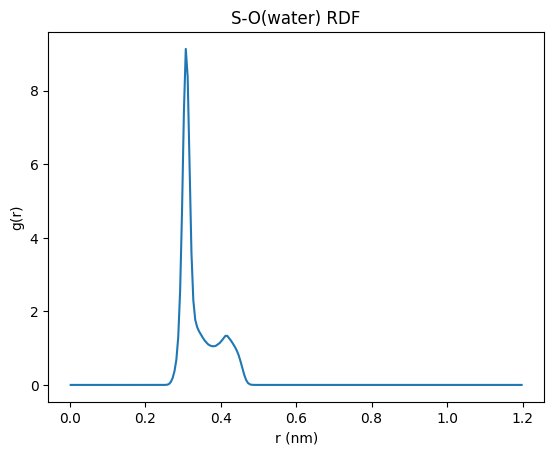

In [141]:
pairs = traj.topology.select_pairs(solute, water_oxygen)

r, g_r = md.compute_rdf(
    traj,
    pairs=pairs,
    r_range=(0.0, 1.2),  # nm
    bin_width=0.005
)

plt.plot(r, g_r)
plt.xlabel("r (nm)")
plt.ylabel("g(r)")
plt.title("S-O(water) RDF")
plt.show()


In [143]:
rho = len(water_oxygen) / traj.unitcell_volumes.mean()  # number density
print("The average number of water molecules per unit volume (number density) is:", rho, "nm^-3")

coord_number = 4 * np.pi * rho * np.trapz(g_r * r**2, r)
print("Coordination number:", coord_number)

first_min_idx = np.argmin(g_r[(r > 0.2) & (r < 0.6)])
r_cut = r[(r > 0.2) & (r < 0.6)][first_min_idx]

coord_number = 4 * np.pi * rho * np.trapz(
    g_r[r <= r_cut] * r[r <= r_cut]**2,
    r[r <= r_cut]
)
print("Coordination number:", coord_number)

The average number of water molecules per unit volume (number density) is: 8.738196139118083 nm^-3
Coordination number: 4.999911779033744
Coordination number: 0.0


/var/folders/tx/zbry1_2j2_57jk0nsqv4m9080000gn/T/ipykernel_58320/2932927383.py:4: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  coord_number = 4 * np.pi * rho * np.trapz(g_r * r**2, r)
/var/folders/tx/zbry1_2j2_57jk0nsqv4m9080000gn/T/ipykernel_58320/2932927383.py:10: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  coord_number = 4 * np.pi * rho * np.trapz(


## Solvent Leakage

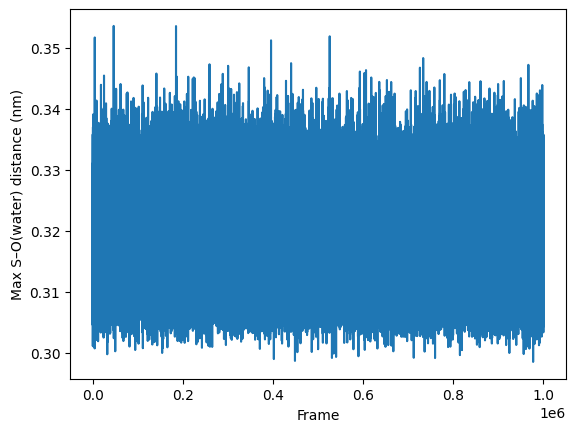

In [149]:
solute_S = top.select("not water and element S")
water_O = top.select("water and element O")

pairs = top.select_pairs(solute_S, water_O)
d = md.compute_distances(traj, pairs)  # shape (frames, waters)

max_dist_per_frame = d.max(axis=1)

plt.plot(max_dist_per_frame)
plt.xlabel("Frame")
plt.ylabel("Max S–O(water) distance (nm)")
plt.show()

Solute is engulfed by solvent over all frames, the droplet does not leak, and water exchange does not occur.
